In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact
import math

In [2]:
def task1(theta1,theta2,a1 = 2 ,a2 = 2):
    p01 = np.array([a1,0])
    p02 = np.array([a1+a2,0])

    rotation1 = np.array([[np.cos(np.radians(theta1)),-np.sin(np.radians(theta1))],[np.sin(np.radians(theta1)),np.cos(np.radians(theta1))]])
    rotation2 = np.array([[np.cos(np.radians(theta2)),-np.sin(np.radians(theta2))],[np.sin(np.radians(theta2)),np.cos(np.radians(theta2))]])

    p11 = rotation1 @ p01
    p12 = rotation1 @ p02

    p22 = rotation2 @ (p12 - p11) + p11
    
    fig01 = plt.figure(num=1,dpi=200)
    ax01 = fig01.add_subplot(1,1,1)
    ax01.grid(ls='--',lw=0.5,color='lightgrey')
    ax01.set_aspect('equal')
    ax01.set(xlim=(-10, 10),ylim=(-10, 10))
    ax01.scatter(p11[0],p11[1],color='g')
    ax01.scatter(p22[0],p22[1],color='k')
    
    X = np.array([0,p11[0],p22[0]])
    Y = np.array([0,p11[1],p22[1]])
    ax01.plot(X,Y)

    return p22[0],p22[1]

In [3]:
interact(task1,theta1=(-180,180,1),theta2=(-180,180,1))

interactive(children=(IntSlider(value=0, description='theta1', max=180, min=-180), IntSlider(value=0, descript…

<function __main__.task1(theta1, theta2, a1=2, a2=2)>

In [9]:
def task11(theta1,theta2,a1 = 2 ,a2 = 2):
    p01 = np.array([a1,0])
    p02 = np.array([a1+a2,0])

    rotation1 = np.array([[np.cos(np.radians(theta1)),-np.sin(np.radians(theta1))],[np.sin(np.radians(theta1)),np.cos(np.radians(theta1))]])
    rotation2 = np.array([[np.cos(np.radians(theta2)),-np.sin(np.radians(theta2))],[np.sin(np.radians(theta2)),np.cos(np.radians(theta2))]])

    p11 = rotation1 @ p01
    p12 = rotation1 @ p02

    p22 = rotation2 @ (p12 - p11) + p11

    return p22[0],p22[1]

In [11]:
def task2_epi(R,r,d):
    n= math.lcm(R,r)/R
    T = np.linspace(0,n*2*np.pi,1000)
    X = []
    Y = []
    for t in T:
        deg = np.degrees(t)
        x,y = task11(deg,(R/r)*deg+180,R+r,d)
        X.append(x)
        Y.append(y)
    fig02 = plt.figure(num=1,dpi=200)
    ax02 = fig02.add_subplot(1,1,1)
    ax02.grid(ls='--',lw=0.5,color='lightgrey')
    ax02.set_aspect('equal')
    #ax01.scatter(p11[0],p11[1],color='g')
    #ax01.scatter(p22[0],p22[1],color='k')
    ax02.plot(X,Y)

def task2_hypo(R,r,d):
    n= math.lcm(R,r)/R
    T = np.linspace(0,n*2*np.pi,1000)
    X = []
    Y = []
    for t in T:
        deg = np.degrees(t)
        x,y = task11(deg,-(R/r)*deg,R-r,d)
        X.append(x)
        Y.append(y)
    fig02 = plt.figure(num=1,dpi=200)
    ax02 = fig02.add_subplot(1,1,1)
    ax02.grid(ls='--',lw=0.5,color='lightgrey')
    ax02.set_aspect('equal')
    #ax01.scatter(p11[0],p11[1],color='g')
    #ax01.scatter(p22[0],p22[1],color='k')
    ax02.plot(X,Y)

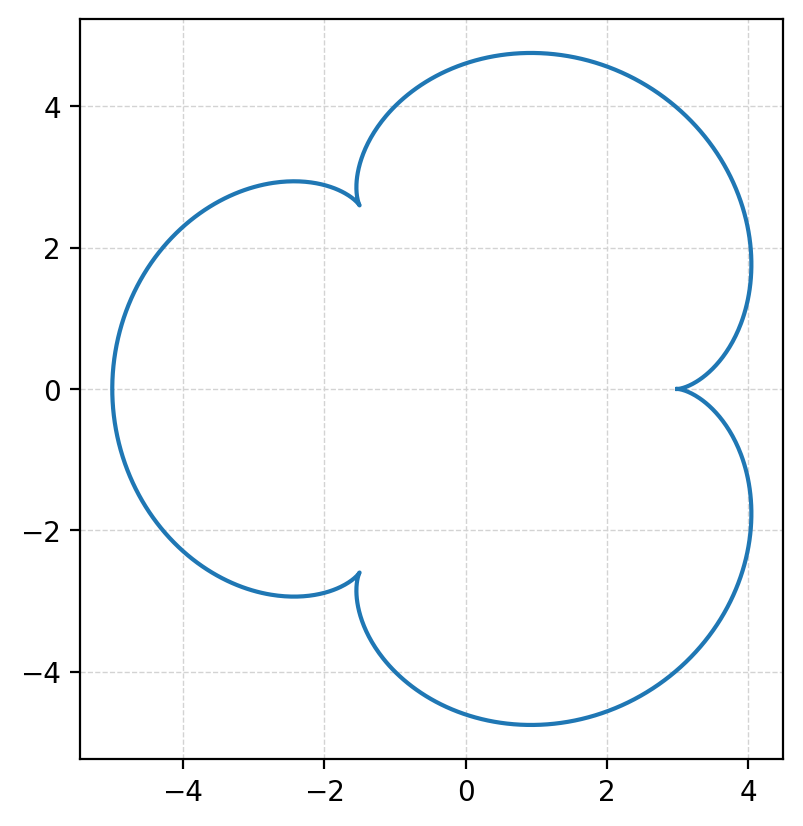

In [43]:
task2_epi(3,1,1)

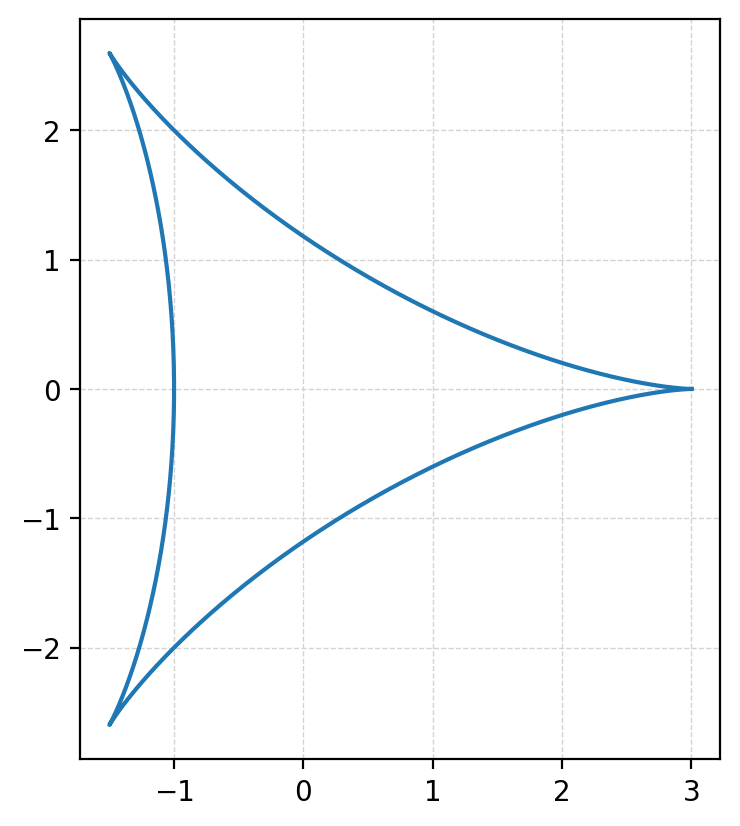

In [45]:
task2_hypo(3,1,1)

In [17]:
def task2_epi1(R,r,d):
    n= math.lcm(R,r)/R
    T = np.linspace(0,n*2*np.pi,1000)
    X = []
    Y = []
    for t in T:
        deg = np.degrees(t)
        x,y = task11(deg,(R/r)*deg+180,R+r,d)
        X.append(x)
        Y.append(y)
        
    return X,Y

def task2_hypo1(R,r,d):
    n= math.lcm(R,r)/R
    T = np.linspace(0,n*2*np.pi,1000)
    X = []
    Y = []
    for t in T:
        deg = np.degrees(t)
        x,y = task11(deg,-(R/r)*deg,R-r,d)
        X.append(x)
        Y.append(y)
        
    return X,Y

def task22(R,r,d,tv):
    n= math.lcm(R,r)/R
    T = np.linspace(0,tv,1000)
    X = []
    Y = []
    for t in T:
        deg = np.degrees(t)
        x,y = task11(deg,(R/r)*deg+180,R+r,d)
        X.append(x)
        Y.append(y)

    return X,Y

In [27]:
def task3(t):
    R = 3
    r = 1
    d = 1
    C = mpatches.Circle(np.array([0,0]),R,fill=False)
    c = mpatches.Circle(np.array([(R+r)*np.cos(t),(R+r)*np.sin(t)]),r,fill=False)
    
    fig03 = plt.figure(num=1,dpi=200)
    ax03 = fig03.add_subplot(1,1,1)
    ax03.grid(ls='--',lw=0.5,color='lightgrey')
    ax03.set_aspect('equal')
    ax03.set(xlim=(-6, 5),ylim=(-5, 5))
    #ax01.scatter(p11[0],p11[1],color='g')
    #ax01.scatter(p22[0],p22[1],color='k')
    x,y = task11(np.degrees(t),(R/r)*np.degrees(t)+180,R+r,d)
    X2 = np.array([(R+r)*np.cos(t),x])
    Y2 = np.array([(R+r)*np.sin(t),y])
    X,Y = task2_epi1(R,r,d)
    ax03.plot(X,Y)
    X1,Y1 = task22(R,r,d,t)
    ax03.plot(X1,Y1)
    ax03.plot(X2,Y2)
    ax03.add_patch(C)
    ax03.add_patch(c)
    ax03.scatter(0,0)
    ax03.scatter((R+r)*np.cos(t),(R+r)*np.sin(t))
    ax03.scatter(x,y)
    #print(X1,Y1)

In [29]:
interact(task3,t=(0,2*np.pi,0.01))

interactive(children=(FloatSlider(value=3.14, description='t', max=6.283185307179586, step=0.01), Output()), _…

<function __main__.task3(t)>

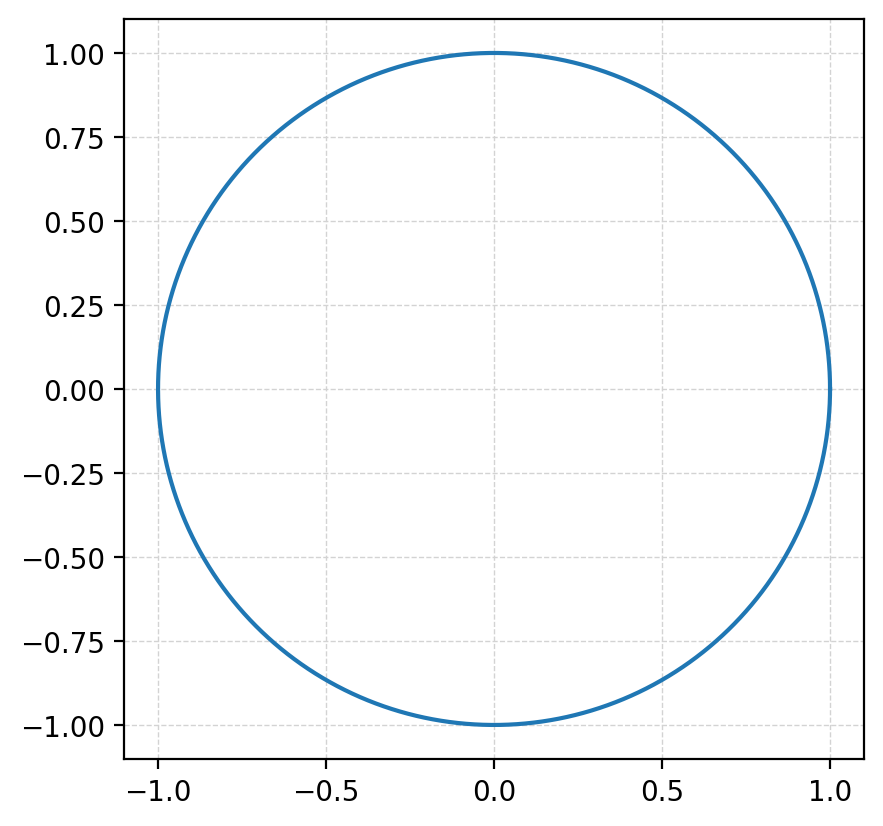

In [31]:
t = np.linspace(0,2*np.pi,1000)
X = np.cos(t)
Y = np.sin(t)

fig04 = plt.figure(num=1,dpi=200)
ax04 = fig04.add_subplot(1,1,1)
ax04.grid(ls='--',lw=0.5,color='lightgrey')
ax04.set_aspect('equal')
#ax04.set(xlim=(-10, 10),ylim=(-10, 10))
ax04.plot(X,Y)

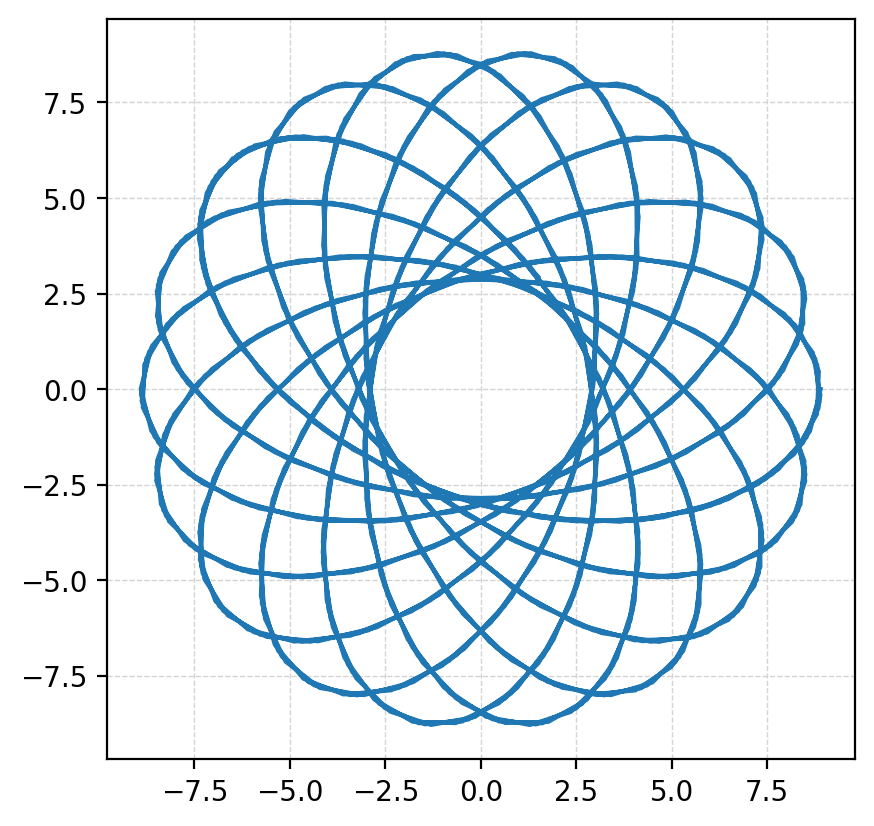

In [57]:
t = np.linspace(0,200*np.pi,1000)
X = 5.89765*np.cos((-np.pi/7)*t) +3*np.cos((np.pi/11)*t)
Y = 5.89765*np.sin((-np.pi/7)*t) +3*np.sin((np.pi/11)*t)

fig04 = plt.figure(num=1,dpi=200)
ax04 = fig04.add_subplot(1,1,1)
ax04.grid(ls='--',lw=0.5,color='lightgrey')
ax04.set_aspect('equal')
#ax04.set(xlim=(-10, 10),ylim=(-10, 10))
ax04.plot(X,Y)

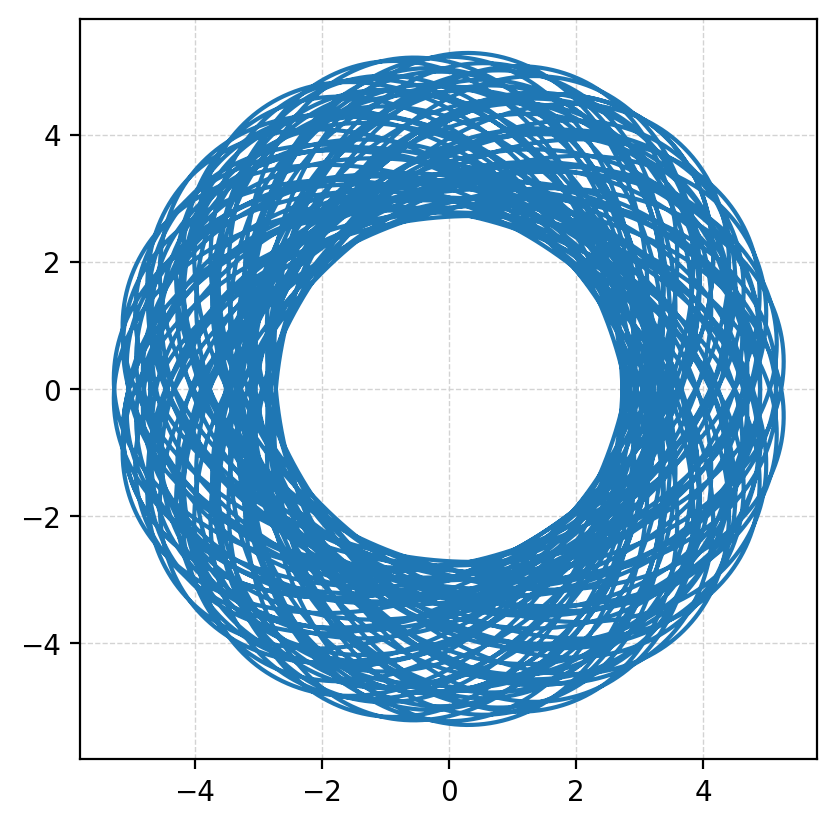

In [67]:
t = np.linspace(0,100*np.pi,100000)
X = 4*np.cos((-np.pi/2)*t) +0.3*np.cos((np.pi/7)*t)-1*np.cos((4*np.pi/11)*t)
Y = 4*np.sin((-np.pi/2)*t) +0.3*np.sin((np.pi/7)*t)-1*np.sin((4*np.pi/11)*t)

fig04 = plt.figure(num=1,dpi=200)
ax04 = fig04.add_subplot(1,1,1)
ax04.grid(ls='--',lw=0.5,color='lightgrey')
ax04.set_aspect('equal')
#ax04.set(xlim=(-10, 10),ylim=(-10, 10))
ax04.plot(X,Y)

In [37]:
def task4(t):
    T = np.linspace(0,t,1000)
    X1 = 4*np.cos((-np.pi/2)*T)
    Y1 = 4*np.sin((-np.pi/2)*T)
    X2 = 0.3*np.cos((np.pi/9)*T)
    Y2 = 0.3*np.sin((np.pi/9)*T)
    X3 = -1*np.cos((4*np.pi/3)*T)
    Y3 = -1*np.sin((4*np.pi/3)*T)
    X = X1 + X2 + X3
    Y = Y1 + Y2 + Y3
    p0 = np.array([0,0])
    p1 = np.array([X1[-1],Y1[-1]])
    p2 = np.array([p1[0]+X2[-1],p1[1]+Y2[-1]])
    p3 = np.array([p2[0]+X3[-1],p2[1]+Y3[-1]])
    fig04 = plt.figure(num=1,dpi=200)
    ax04 = fig04.add_subplot(1,1,1)
    ax04.grid(ls='--',lw=0.5,color='lightgrey')
    ax04.set_aspect('equal')
    ax04.set(xlim=(-6, 6),ylim=(-6, 6))
    ax04.arrow(*p0,*p1,length_includes_head=True, width=0.005, head_width=0.05, color='k')
    ax04.arrow(*p1,X2[-1],Y2[-1],length_includes_head=True, width=0.005, head_width=0.05, color='r')
    ax04.arrow(*p2,X3[-1],Y3[-1],length_includes_head=True, width=0.005, head_width=0.05, color='g')
    ax04.arrow(*p0,*p3,length_includes_head=True, width=0.005, head_width=0.05, color='yellow')
    ax04.plot(X,Y)
interact(task4,t=(0,2*np.pi,0.01))

interactive(children=(FloatSlider(value=3.14, description='t', max=6.283185307179586, step=0.01), Output()), _…

<function __main__.task4(t)>

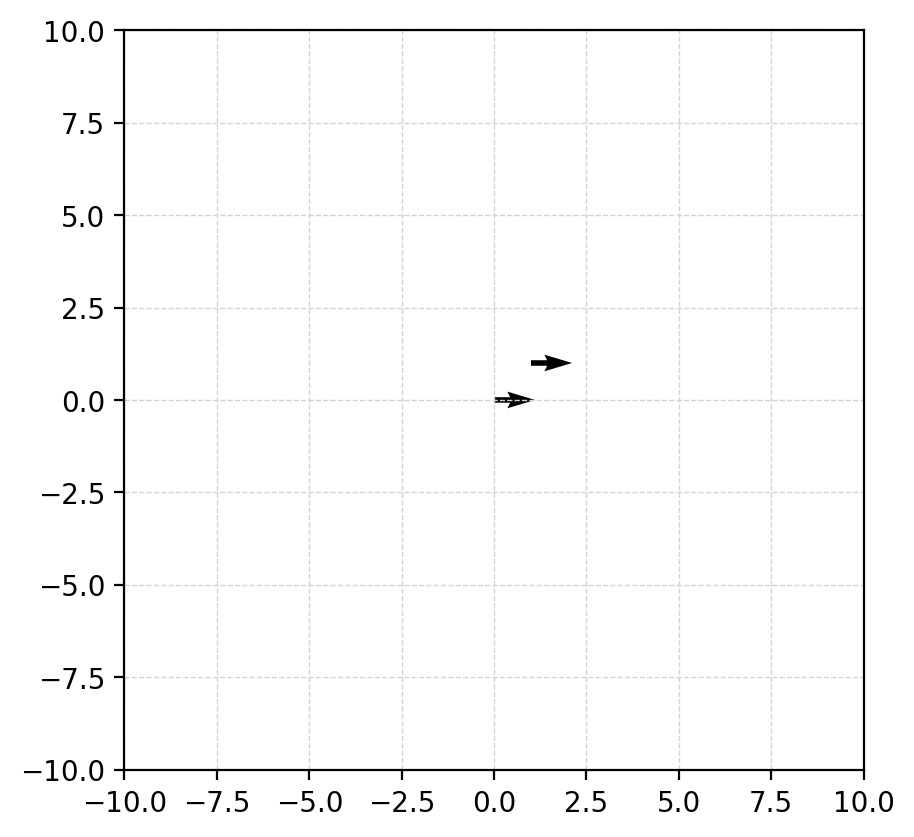

In [39]:
fig04 = plt.figure(num=1,dpi=200)
ax04 = fig04.add_subplot(1,1,1)
ax04.grid(ls='--',lw=0.5,color='lightgrey')
ax04.set_aspect('equal')
ax04.set(xlim=(-10, 10),ylim=(-10, 10))
X = np.array([0,1])
Y = np.array([0,1])
ax04.quiver(X,Y,1,0)